In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

from scipy.special import comb as n_choose_k
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
import pickle

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from itertools import combinations
from collections import defaultdict
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sys

device = torch.device('cuda')
device

device(type='cuda')

In [4]:
# Parameters
seed = 7012025
C = np.inf # no regularisation for lin. regression
power = 1 # uniform density
D = 1000 # number of data samples
N = 100 # number of sources
K = 10 # sparsity
num_ood = N // 2 # how many new OOD sources
M = int(np.ceil(K * np.log(N / K) * 2)) # Compressed Sensing bound
num_ood, M

(50, 47)

In [5]:
# mcc
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr
import numpy as np
import torch
#import munkres  # broken!


def pad(a, num_col):
    # pad a to have num_col columns
    diff = num_col - a.shape[1]
    noise = np.random.normal(0, 1, (a.shape[0], diff))
    return np.concatenate([a, noise], axis=1)
    
    
def normalize(x):
    # Center the data
    x_centered = x - np.mean(x, axis=0, keepdims=True)
    # Normalize by the L2 norm of the centered data
    x_normed = x_centered / np.linalg.norm(x_centered, axis=0, keepdims=True)
    return x_normed


def compute_correlation(a, b):
    # The dot product of centered and normalized vectors gives the correlation.
    return normalize(a).T @ normalize(b)


def compute_matches(cost):
    matches = [(row_ind, col_ind) for (row_ind, col_ind) in zip(*linear_sum_assignment(cost))]
    return matches


def compute_mcc(a, b, seed=42, return_correlations=False, return_matches=False):
    if type(a) == torch.Tensor:
        a = a.detach().cpu().numpy()
    if type(b) == torch.Tensor:
        b = b.detach().cpu().numpy()
    if a.shape[1] < b.shape[1]:
        np.random.seed(seed)
        a = pad(a, b.shape[1])
    elif b.shape[1] < a.shape[1]:
        np.random.seed(seed)
        b = pad(b, a.shape[1])
    correlations = compute_correlation(a, b)
    bad_ind = np.isinf(correlations)
    correlations[bad_ind] = 0
    bad_ind = np.isnan(correlations)
    correlations[bad_ind] = 0
    cost = - np.abs(correlations)
    matches = compute_matches(cost)
    mcc = np.mean([abs(correlations[i, j]) for i, j in matches])
    output = [mcc]
    if return_correlations:
        output += [correlations]
    if return_matches:
        output += [matches]
    return output

In [6]:
# LR scheduler, unsupervised learning seems ill conditioned, needs greedy lr increases...
from torch.optim.lr_scheduler import _LRScheduler


class AdaptiveLR(object):
    """
    A learning rate scheduler that increases the learning rate when the loss
    is decreasing and decreases it when the loss is stagnating or increasing.
    """
    def __init__(self, optimizer, mode='min', factor=0.5, increase_factor=1.1, 
                 patience_increase=1, patience_decrease=2, min_lr=1e-6, 
                 max_lr=1e0, verbose=False):
        
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.increase_factor = increase_factor
        self.patience_increase = patience_increase
        self.patience_decrease = patience_decrease
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.verbose = verbose

        self.best_loss = float('inf') if self.mode == 'min' else float('-inf')
        self.num_bad_epochs = 0
        self.num_good_epochs = 0
        
        self.last_epoch = 0

    def step(self, metrics):
        current_loss = metrics

        if self.mode == 'min':
            if current_loss < self.best_loss:
                # Loss is improving, reset bad epochs counter and increment good epochs
                self.best_loss = current_loss
                self.num_bad_epochs = 0
                self.num_good_epochs += 1
                
                # Check if we should increase LR
                if self.num_good_epochs >= self.patience_increase:
                    self._adjust_lr(self.increase_factor)
                    self.num_good_epochs = 0 # Reset counter after increase
            else:
                # Loss is not improving, reset good epochs and increment bad epochs
                self.num_good_epochs = 0
                self.num_bad_epochs += 1
                
                # Check if we should decrease LR
                if self.num_bad_epochs >= self.patience_decrease:
                    self._adjust_lr(self.factor)
                    self.num_bad_epochs = 0 # Reset counter after decrease
        
        self.last_epoch += 1

    def _adjust_lr(self, factor):
        """Adjusts the learning rate by a given factor for all parameter groups."""
        for i, param_group in enumerate(self.optimizer.param_groups):
            old_lr = float(param_group['lr'])
            new_lr = old_lr * factor
            
            # Clamp the new learning rate within the defined bounds
            new_lr = max(self.min_lr, new_lr)
            new_lr = min(self.max_lr, new_lr)
            
            if new_lr != old_lr:
                param_group['lr'] = new_lr
                if self.verbose:
                    print(f"Epoch {self.last_epoch}: adjusting learning rate "
                          f"of group {i} from {old_lr:.6f} to {new_lr:.6f}.")

# Game Plan

### IID means either:

a) first index and any of the IID distractors [cow and grass]

b) NOT the first index and ANY of the distractors [grass and sand]

### OOD means:

c) first index and any of the OOD distractors [cow and sand]

In [7]:
# sampling functions

def sample_comb(ind, N=N, K=K, power=power):
    """given K indices, sample sources"""
    z = np.zeros(N)
    z[ind] = np.random.uniform(0, 1, K) ** power
    return z

def sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood):
    """include first index and sample randomly from IID"""
    if seed is not None:
        np.random.seed(seed)
    ind_distractors = np.random.choice(
        np.arange(1, N - num_ood), K - 1, replace=False)
    # add first latent
    ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood):
    """sample randomly from all but first"""
    if seed is not None:
        np.random.seed(seed)
    ind = np.random.choice(np.arange(1, N), K, replace=False)
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood):
    """include first index and sample randomly from OOD"""
    if seed is not None:
        np.random.seed(seed)
    ind_distractors = np.random.choice(
        np.arange(N - num_ood, N), K - 1, replace=False)
    # add first latent
    ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_iid(seed=None, N=N, K=K, num_ood=num_ood):
    """only sample from IID latent combinations"""
    if seed is not None:
        np.random.seed(seed)
    # is variable of interest in sample?
    first_one_in = np.random.binomial(n=1, p=.5)
    if first_one_in: # a) setting
        return sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood)
    else: # b) setting
        return sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood)

def sample_ood(seed=None, N=N, K=K, num_ood=num_ood):
    return sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood)

def sample_all(seed=None, N=N, K=K):
    """no IID/OOD split, just sample all"""
    if seed is not None:
        np.random.seed(seed)
    ind = np.random.choice(np.arange(N), K, replace=False)
    z = sample_comb(ind, N=N, K=K)
    return z

In [8]:
sample_setting_a(), sample_setting_b(), sample_setting_c()

(array([0.79633899, 0.        , 0.        , 0.6791451 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.04614972, 0.51412506, 0.56900236,
        0.93868047, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.66647325,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.85894069, 0.        ,
        0.05330403, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.00993874, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [9]:
# Full example: train encoder with matrix A...

# or, at least, verify that some nonlinear function can solve it (Isa's MLP-SAE) – does is generalize?

In [10]:
# lazy example (might not be perfect), just draw random A
np.random.seed(seed)
# https://en.wikipedia.org/wiki/Restricted_isometry_property
A = np.random.normal(0, 1, (M, N)) # random normal has RIP -> CS works =)
A /= np.linalg.norm(A, axis=0, keepdims=True)
A.min(), A.max(), A.shape

(np.float64(-0.4961868590529581), np.float64(0.46982081349788496), (47, 100))

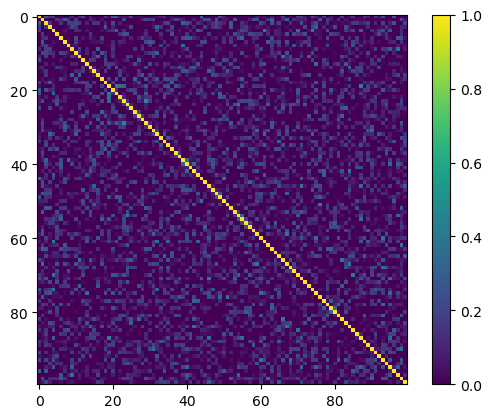

In [11]:
plt.imshow(A.T @ A, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()

In [12]:
# generate data
np.random.seed(seed)

Z_iid = np.array([sample_iid() for _ in range(D)])
Y_iid = Z_iid @ A.T
label_iid = Z_iid[:, 0] > .5

Z_ood = np.array([sample_ood() for _ in range(D)])
Y_ood = Z_ood @ A.T
label_ood = Z_ood[:, 0] > .5

Z_iid.shape, Y_iid.shape, label_iid[:10], np.mean(label_iid)

((1000, 100),
 (1000, 47),
 array([False, False, False, False, False, False,  True, False, False,
        False]),
 np.float64(0.237))

In [13]:
# test linear probe
clf = LogisticRegression(C=C).fit(Z_iid, label_iid)

acc_iid = clf.score(Z_iid, label_iid)
acc_ood = clf.score(Z_ood, label_ood)
print(f'In source (Z) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

clf = LogisticRegression(C=C).fit(Y_iid, label_iid)

acc_iid = clf.score(Y_iid, label_iid)
acc_ood = clf.score(Y_ood, label_ood)
print(f'In observation (Y=AZ) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

In source (Z) space: acc IID: 1.000, acc OOD: 0.950
In observation (Y=AZ) space: acc IID: 0.979, acc OOD: 0.614


# Supervised Sparse Coding

In [ ]:
# Sparse code (supervised) setting
# 1) infer Z_iid_ and Z_ood_
# 2) On Z_iid_, train linear classifier - how good (iid and ood)?
supervised = True

# get some intution how hard the problem is, starting from the mixed observations
ind_iid = Z_iid.std(0) > 0
print('MCC(Z_iid, Y_iid)=', compute_mcc(Y_iid, Z_iid[:, ind_iid]))
ind_ood = Z_ood.std(0) > 0
print('MCC(Z_ood, Y_ood)=', compute_mcc(Y_ood, Z_ood[:, ind_ood]))

inputs_iid = torch.tensor(Y_iid, dtype=torch.float32, device=device)
inputs_ood = torch.tensor(Y_ood, dtype=torch.float32, device=device)

lr = 1e-2
if supervised:
    max_steps = 100000
else: # unsupervised takes longer
    max_steps = 250000
lams = np.geomspace(1e-4, 1e0, 10)

nonlinearity = torch.nn.functional.softplus # worked best
# nonlinearity = torch.exp
# nonlinearity = torch.nn.functional.relu
# nonlinearity = torch.nn.functional.gelu

logs = []
for j, lam in enumerate(lams):
    print('%s/%s, lambda=%.6e' % (j, len(lams), lam))
    torch.manual_seed(seed + int(lam * 1e4))
    
    log_Z_iid_ = torch.randn(inputs_iid.shape[0], N, device=device).requires_grad_()
    log_Z_ood_ = torch.randn(inputs_ood.shape[0], N, device=device).requires_grad_()
    log_Z_iid_.data -= 10 # good for softplus, small init
    log_Z_ood_.data -= 10

    params = [log_Z_iid_, log_Z_ood_]

    if supervised:
        A_ = torch.tensor(A, dtype=torch.float32, device=device)
        A_norms = torch.linalg.norm(A_, dim=0) # remains fixed
    else:
        A_ = torch.randn(A.shape, device=device).requires_grad_()
        A_.data *= 1e-3 # small init
        params += [A_]

    optim = torch.optim.Adam(params, lr=lr)
    scheduler = AdaptiveLR(optim, verbose=True)
    
    log = {
        'lam': lam, 'i': [], 'lr': [], 'avg_loss': [], 
        'mcc_A': [], 
        'corr_first_iid': [], 'corr_first_ood': [], 
        'mse_iid': [], 'mse_ood': [], 
        'l1_iid': [], 'l1_ood': [], 
        'mcc_iid': [], 'mcc_ood': [], 
        'acc_iid_all': [], 'acc_ood_all': [], 
        'acc_iid_best': [], 'acc_ood_best': []
    }
    run_loss = []
    for i in tqdm(range(max_steps + 1)):
        Z_iid_ = nonlinearity(log_Z_iid_)
        Z_ood_ = nonlinearity(log_Z_ood_)
        rec_iid = Z_iid_ @ A_.T
        rec_ood = Z_ood_ @ A_.T.detach() # A_ is only trained on iid
        mse_iid = torch.mean((inputs_iid - rec_iid)**2)
        mse_ood = torch.mean((inputs_ood - rec_ood)**2)
        if not supervised:
            A_norms = torch.linalg.norm(A_, dim=0)
        l1_iid = torch.mean(torch.abs(Z_iid_) * A_norms)
        l1_ood = torch.mean(torch.abs(Z_ood_) * A_norms.detach()) # A_ is only trained on iid
        loss = mse_iid + mse_ood + lam * (l1_iid + l1_ood)
        optim.zero_grad()
        loss.backward()
        optim.step()
        run_loss.append(loss.item())

        # logging
        if i>0 and not i % 5000:
            avg_loss = np.mean(run_loss)
            run_loss = []

            # compute MCCs
            Z_iid_ = Z_iid_.detach().cpu().numpy()
            Z_ood_ = Z_ood_.detach().cpu().numpy()
            mcc_iid = compute_mcc(Z_iid[:, ind_iid], Z_iid)[0]
            mcc_ood = compute_mcc(Z_ood[:, ind_ood], Z_ood_)[0]
            # shape of A: M x N, we want the mcc over all N columns
            mcc_A = compute_mcc(A.T, A_.T.detach().cpu().numpy())[0]

            # pick best matching dim on iid
            correlations_iid = compute_correlation(Z_iid_, label_iid[:, None])[:, 0]
            ind_fit_first = np.argmax(abs(correlations_iid))
            corr_first_iid = pearsonr(Z_iid[:, 0], Z_iid_[:, ind_fit_first])[0]
            corr_first_ood = pearsonr(Z_ood[:, 0], Z_ood_[:, ind_fit_first])[0]

            # regression from best latent 
            clf = LogisticRegression(C=C).fit(Z_iid_[:, ind_fit_first][:, None], label_iid)
            acc_iid_best = clf.score(Z_iid_[:, ind_fit_first][:, None], label_iid)
            acc_ood_best = clf.score(Z_ood_[:, ind_fit_first][:, None], label_ood)

            # regression from all learned latents
            clf = LogisticRegression(C=C).fit(Z_iid_, label_iid)
            acc_iid_all = clf.score(Z_iid_, label_iid)
            acc_ood_all = clf.score(Z_ood_, label_ood)

            log['i'].append(i)
            log['lr'].append(optim.param_groups[0]['lr'])
            log['avg_loss'].append(avg_loss)
            log['mcc_A'].append(mcc_A)
            log['corr_first_iid'].append(corr_first_iid)
            log['corr_first_ood'].append(corr_first_ood)
            log['mse_iid'].append(mse_iid.item())
            log['mse_ood'].append(mse_ood.item())
            log['l1_iid'].append(l1_iid.item())
            log['l1_ood'].append(l1_ood.item())
            log['mcc_iid'].append(mcc_iid)
            log['mcc_ood'].append(mcc_ood)
            log['acc_iid_all'].append(acc_iid_all)
            log['acc_ood_all'].append(acc_ood_all)
            log['acc_iid_best'].append(acc_iid_best)
            log['acc_ood_best'].append(acc_ood_best)

            print(
                'i=%s, ' % i +\
                'avg_loss=%4e, ' % avg_loss +\
                'mse_iid=%4e, ' % mse_iid +\
                'mse_ood=%4e, ' % mse_ood +\
                'l1_iid=%4e, ' % l1_iid +\
                'l1_ood=%4e, ' % l1_ood +\
                'mcc_A=%4f, ' % mcc_A +\
                'mcc_iid=%4f, ' % mcc_iid +\
                'mcc_ood=%4f, ' % mcc_ood +\
                'corr_first_iid=%4f, ' % corr_first_iid +\
                'corr_first_ood=%4f, ' % corr_first_ood +\
                'acc_iid_best=%4f, ' % acc_iid_best +\
                'acc_ood_best=%4f, ' % acc_ood_best
            )

            # Update the scheduler
            scheduler.step(avg_loss)


    # after training
    Z_iid_ = nonlinearity(log_Z_iid_)
    Z_ood_ = nonlinearity(log_Z_ood_)
    log['Z_iid_'] = Z_iid_.detach().cpu().numpy()
    log['Z_ood_'] = Z_ood_.detach().cpu().numpy()
    log['A_'] = A_.detach().cpu().numpy()
    logs.append(log)

MCC(Z_iid, Y_iid)= [np.float64(0.1766677337357744)]
MCC(Z_ood, Y_ood)= [np.float64(0.32338388173747745)]
0/10, lambda=1.000000e-04


  5%|▌         | 5069/100001 [00:15<04:26, 356.59it/s]

i=5000, avg_loss=3.567213e-02, mse_iid=2.912113e-03, mse_ood=2.977418e-03, l1_iid=5.256438e-02, l1_ood=5.325054e-02, mcc_A=1.000000, mcc_iid=1.000000, mcc_ood=0.480103, corr_first_iid=0.883280, corr_first_ood=0.768515, acc_iid_best=0.933000, acc_ood_best=0.853000, 
Epoch 0: adjusting learning rate of group 0 from 0.010000 to 0.011000.


 10%|█         | 10069/100001 [00:28<04:05, 366.70it/s]

i=10000, avg_loss=3.160862e-03, mse_iid=7.970285e-04, mse_ood=8.833451e-04, l1_iid=5.441399e-02, l1_ood=5.535033e-02, mcc_A=1.000000, mcc_iid=1.000000, mcc_ood=0.510061, corr_first_iid=0.944989, corr_first_ood=0.876485, acc_iid_best=0.964000, acc_ood_best=0.911000, 
Epoch 1: adjusting learning rate of group 0 from 0.011000 to 0.012100.


...

 50%|█████     | 50113/100001 [01:58<00:46, 1071.71it/s]

i=50000, avg_loss=4.839208e-05, mse_iid=1.297957e-05, mse_ood=1.791507e-05, l1_iid=5.302576e-02, l1_ood=5.368419e-02, mcc_A=1.000000, mcc_iid=1.000000, mcc_ood=0.535176, corr_first_iid=0.993459, corr_first_ood=0.971057, acc_iid_best=0.992000, acc_ood_best=0.976000, 
Epoch 9: adjusting learning rate of group 0 from 0.023579 to 0.025937.


 55%|█████▌    | 55055/100001 [02:09<01:20, 558.66it/s] 

i=55000, avg_loss=3.760000e-05, mse_iid=1.015269e-05, mse_ood=1.332038e-05, l1_iid=5.296017e-02, l1_ood=5.354701e-02, mcc_A=1.000000, mcc_iid=1.000000, mcc_ood=0.535028, corr_first_iid=0.993655, corr_first_ood=0.971305, acc_iid_best=0.992000, acc_ood_best=0.978000, 
Epoch 10: adjusting learning rate of group 0 from 0.025937 to 0.028531.


 59%|█████▉    | 59260/100001 [02:18<01:22, 492.23it/s] 

In [ ]:
# save
with open('10_sparse_codingd_supervised.pickle', 'wb') as handle:
    pickle.dump(logs, handle, protocol=pickle.HIGHEST_PROTOCOL)

# with open('10_sparse_codingd_supervised.pickle', 'rb') as handle:
#     logs = pickle.load(handle)

In [ ]:
# what you want to plot:
labels = ['avg_loss', 'mse', 'l1', 'mcc', 'corr_first', 
          'acc_iid_all', 'acc_ood_all', 'acc_iid_best', 'acc_ood_best']

plt.figure(figsize=(9, 9))
for i, k in enumerate(labels):
    plt.subplot(3, 3, i + 1)
    if i == 1:
        plt.title('Unsupervised high-D sparse coding')
    plt.plot(
        lams,
        [l[k][-1] for l in logs],
        '.-',
        label='last',
    )
    plt.plot(
        lams,
        [np.max(l[k]) for l in logs],
        '.-',
        label='highest',
    )
    plt.semilogx()
    plt.xlabel('lambda')
    plt.ylabel(k)
    plt.grid()
    plt.legend()
    if i > 2:
        plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Unsupervised Sparse Coding

In [ ]:
# Sparse code (unsupervised) setting
# 1) Learn matrix A (=dictionary) on Y_iid
# 2) infer Z_iid_ and Z_ood_ [can be done at same time as step 1) or at the end]
# 3) On Z_iid_, train linear classifier - how good (iid and ood)?
supervised = False

# get some intution how hard the problem is, starting from the mixed observations
ind_iid = Z_iid.std(0) > 0
print('MCC(Z_iid, Y_iid)=', compute_mcc(Y_iid, Z_iid[:, ind_iid]))
ind_ood = Z_ood.std(0) > 0
print('MCC(Z_ood, Y_ood)=', compute_mcc(Y_ood, Z_ood[:, ind_ood]))

inputs_iid = torch.tensor(Y_iid, dtype=torch.float32, device=device)
inputs_ood = torch.tensor(Y_ood, dtype=torch.float32, device=device)

lr = 1e-2
if supervised:
    max_steps = 100000
else: # unsupervised takes longer
    max_steps = 250000
lams = np.geomspace(1e-4, 1e0, 10)

nonlinearity = torch.nn.functional.softplus # worked best
# nonlinearity = torch.exp
# nonlinearity = torch.nn.functional.relu
# nonlinearity = torch.nn.functional.gelu

logs = []
for j, lam in enumerate(lams):
    print('%s/%s, lambda=%.6e' % (j, len(lams), lam))
    torch.manual_seed(seed + int(lam * 1e4))
    
    log_Z_iid_ = torch.randn(inputs_iid.shape[0], N, device=device).requires_grad_()
    log_Z_ood_ = torch.randn(inputs_ood.shape[0], N, device=device).requires_grad_()
    log_Z_iid_.data -= 10 # good for softplus, small init
    log_Z_ood_.data -= 10

    params = [log_Z_iid_, log_Z_ood_]

    if supervised:
        A_ = torch.tensor(A, dtype=torch.float32, device=device)
        A_norms = torch.linalg.norm(A_, dim=0) # remains fixed
    else:
        A_ = torch.randn(A.shape, device=device).requires_grad_()
        A_.data *= 1e-3 # small init
        params += [A_]

    optim = torch.optim.Adam(params, lr=lr)
    scheduler = AdaptiveLR(optim, verbose=True)
    
    log = {
        'lam': lam, 'i': [], 'lr': [], 'avg_loss': [], 
        'mcc_A': [], 
        # if mcc_A is high but mcc (on latents) low, then we need to run step 2) 
        # again separately after training to see if we can get a better estimate.
        'corr_first_iid': [], 'corr_first_ood': [], 
        'mse_iid': [], 'mse_ood': [], 
        'l1_iid': [], 'l1_ood': [], 
        'mcc_iid': [], 'mcc_ood': [], 
        'acc_iid_all': [], 'acc_ood_all': [], 
        'acc_iid_best': [], 'acc_ood_best': []
    }
    run_loss = []
    for i in tqdm(range(max_steps + 1)):
        Z_iid_ = nonlinearity(log_Z_iid_)
        Z_ood_ = nonlinearity(log_Z_ood_)
        rec_iid = Z_iid_ @ A_.T
        rec_ood = Z_ood_ @ A_.T.detach() # A_ is only trained on iid
        mse_iid = torch.mean((inputs_iid - rec_iid)**2)
        mse_ood = torch.mean((inputs_ood - rec_ood)**2)
        if not supervised:
            A_norms = torch.linalg.norm(A_, dim=0)
        l1_iid = torch.mean(torch.abs(Z_iid_) * A_norms)
        l1_ood = torch.mean(torch.abs(Z_ood_) * A_norms.detach()) # A_ is only trained on iid
        loss = mse_iid + mse_ood + lam * (l1_iid + l1_ood)
        optim.zero_grad()
        loss.backward()
        optim.step()
        run_loss.append(loss.item())

        # logging
        if i>0 and not i % 5000:
            avg_loss = np.mean(run_loss)
            run_loss = []

            # compute MCCs
            Z_iid_ = Z_iid_.detach().cpu().numpy()
            Z_ood_ = Z_ood_.detach().cpu().numpy()
            mcc_iid = compute_mcc(Z_iid[:, ind_iid], Z_iid_)[0]
            mcc_ood = compute_mcc(Z_ood[:, ind_ood], Z_ood_)[0]
            # shape of A: M x N, we want the mcc over all N columns
            mcc_A = compute_mcc(A.T, A_.T.detach().cpu().numpy())[0]

            # pick best matching dim on iid
            correlations_iid = compute_correlation(Z_iid_, label_iid[:, None])[:, 0]
            ind_fit_first = np.argmax(abs(correlations_iid))
            corr_first_iid = pearsonr(Z_iid[:, 0], Z_iid_[:, ind_fit_first])[0]
            corr_first_ood = pearsonr(Z_ood[:, 0], Z_ood_[:, ind_fit_first])[0]

            # regression from best latent 
            clf = LogisticRegression(C=C).fit(Z_iid_[:, ind_fit_first][:, None], label_iid)
            acc_iid_best = clf.score(Z_iid_[:, ind_fit_first][:, None], label_iid)
            acc_ood_best = clf.score(Z_ood_[:, ind_fit_first][:, None], label_ood)

            # regression from all learned latents
            clf = LogisticRegression(C=C).fit(Z_iid_, label_iid)
            acc_iid_all = clf.score(Z_iid_, label_iid)
            acc_ood_all = clf.score(Z_ood_, label_ood)

            log['i'].append(i)
            log['lr'].append(optim.param_groups[0]['lr'])
            log['avg_loss'].append(avg_loss)
            log['mcc_A'].append(mcc_A)
            log['corr_first_iid'].append(corr_first_iid)
            log['corr_first_ood'].append(corr_first_ood)
            log['mse_iid'].append(mse_iid.item())
            log['mse_ood'].append(mse_ood.item())
            log['l1_iid'].append(l1_iid.item())
            log['l1_ood'].append(l1_ood.item())
            log['mcc_iid'].append(mcc_iid)
            log['mcc_ood'].append(mcc_ood)
            log['acc_iid_all'].append(acc_iid_all)
            log['acc_ood_all'].append(acc_ood_all)
            log['acc_iid_best'].append(acc_iid_best)
            log['acc_ood_best'].append(acc_ood_best)

            print(
                'i=%s, ' % i +\
                'avg_loss=%4e, ' % avg_loss +\
                'mse_iid=%4e, ' % mse_iid +\
                'mse_ood=%4e, ' % mse_ood +\
                'l1_iid=%4e, ' % l1_iid +\
                'l1_ood=%4e, ' % l1_ood +\
                'mcc_A=%4f, ' % mcc_A +\
                'mcc_iid=%4f, ' % mcc_iid +\
                'mcc_ood=%4f, ' % mcc_ood +\
                'corr_first_iid=%4f, ' % corr_first_iid +\
                'corr_first_ood=%4f, ' % corr_first_ood +\
                'acc_iid_best=%4f, ' % acc_iid_best +\
                'acc_ood_best=%4f, ' % acc_ood_best
            )

            # Update the scheduler
            scheduler.step(avg_loss)


    # after training
    Z_iid_ = nonlinearity(log_Z_iid_)
    Z_ood_ = nonlinearity(log_Z_ood_)
    log['Z_iid_'] = Z_iid_.detach().cpu().numpy()
    log['Z_ood_'] = Z_ood_.detach().cpu().numpy()
    log['A_'] = A_.detach().cpu().numpy()
    logs.append(log)

In [ ]:
# save
with open('10_sparse_codingd_unsupervised.pickle', 'wb') as handle:
    pickle.dump(logs, handle, protocol=pickle.HIGHEST_PROTOCOL)

# with open('10_sparse_codingd_unsupervised.pickle', 'rb') as handle:
#     logs = pickle.load(handle)

In [ ]:
# what you want to plot:
labels = ['avg_loss', 'mse', 'l1', 'mcc', 'corr_first', 
          'acc_iid_all', 'acc_ood_all', 'acc_iid_best', 'acc_ood_best']

plt.figure(figsize=(9, 9))
for i, k in enumerate(labels):
    plt.subplot(3, 3, i + 1)
    if i == 1:
        plt.title('Unsupervised high-D sparse coding')
    plt.plot(
        lams,
        [l[k][-1] for l in logs],
        '.-',
        label='last',
    )
    plt.plot(
        lams,
        [np.max(l[k]) for l in logs],
        '.-',
        label='highest',
    )
    plt.semilogx()
    plt.xlabel('lambda')
    plt.ylabel(k)
    plt.grid()
    plt.legend()
    if i > 2:
        plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()